In [4]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

In [5]:
!git clone https://github.com/Liza228ko/DM2026-Assignment-2.git
%cd DM2026-Assignment-2

Cloning into 'DM2026-Assignment-2'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 41 (delta 9), reused 24 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 2.47 MiB | 9.02 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/DM2026-Assignment-2/DM2026-Assignment-2


In [ ]:
!pip install --upgrade jupyter_client

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Load the dataset from the data folder
file_path = 'data/mobile_price.csv'
df = pd.read_csv(file_path)

# Separate features (X) and target (y)
X = df.drop(columns=['price_range']).values
y = df['price_range'].values

print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (2000, 21)


In [ ]:
# 2(a) Split the data: 60% Train, 20% Validation, 20% Test
# Step 1: Split into 60% Train and 40% Temp (which will become Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, shuffle=True)

# Step 2: Split the 40% Temp evenly into 20% Validation and 20% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)

print(f"Training set: {X_train.shape[0]} samples (60%)")
print(f"Validation set: {X_val.shape[0]} samples (20%)")
print(f"Testing set: {X_test.shape[0]} samples (20%)\n")

# Train the SVM Classifier with C=1.0
svm_clf = SVC(C=1.0, random_state=42)
svm_clf.fit(X_train, y_train)

# Evaluation function
def evaluate_model(model, X_data, y_data, dataset_name):
    predictions = model.predict(X_data)
    acc = accuracy_score(y_data, predictions)
    # Using 'weighted' because price_range has 4 classes (0, 1, 2, 3)
    f1 = f1_score(y_data, predictions, average='weighted')
    print(f"--- {dataset_name} ---")
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f}\n")

print("Results for Q2(a) with C=1.0:")
evaluate_model(svm_clf, X_train, y_train, "Training Data")
evaluate_model(svm_clf, X_val, y_val, "Validation Data")
evaluate_model(svm_clf, X_test, y_test, "Testing Data")

Training set: 1200 samples (60%)
Validation set: 400 samples (20%)
Testing set: 400 samples (20%)

Results for Q2(a) with C=1.0:
--- Training Data ---
Accuracy: 0.9450 | F1-Score: 0.9445

--- Validation Data ---
Accuracy: 0.9450 | F1-Score: 0.9448

--- Testing Data ---
Accuracy: 0.9575 | F1-Score: 0.9573



C          | Train Acc  | Val Acc    | Test Acc  
--------------------------------------------------
0.001      | 0.2550     | 0.2450     | 0.2400    
0.01       | 0.4908     | 0.4875     | 0.4425    
0.1        | 0.9050     | 0.9025     | 0.9000    
1          | 0.9450     | 0.9450     | 0.9575    
10         | 0.9658     | 0.9575     | 0.9650    
100        | 0.9792     | 0.9725     | 0.9775    
1000       | 0.9900     | 0.9700     | 0.9775    
10000      | 0.9975     | 0.9700     | 0.9650    


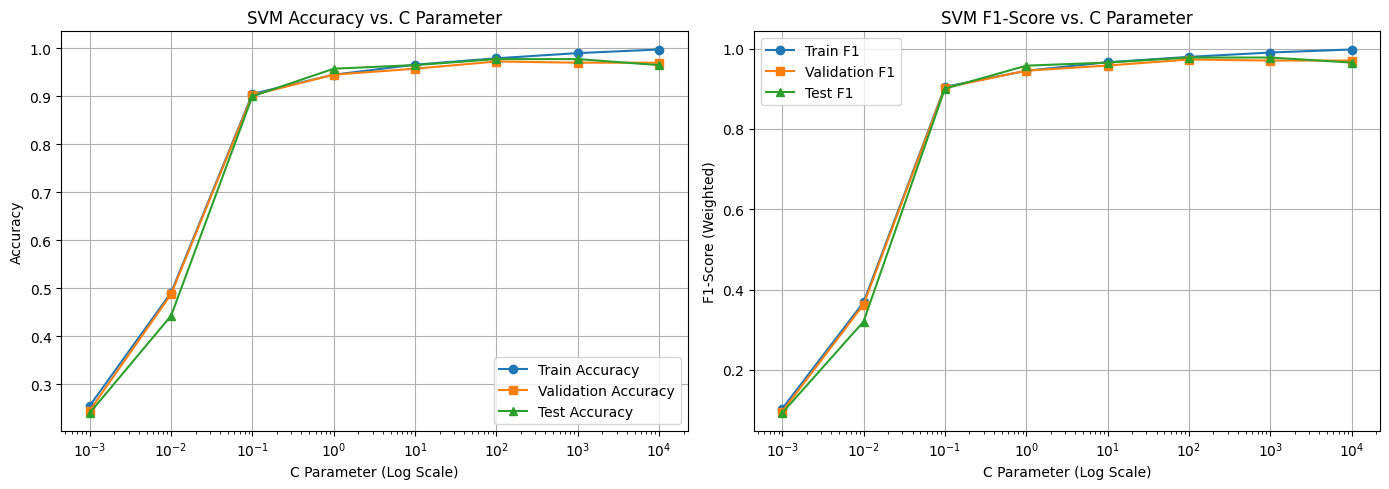

In [ ]:
# 2(b) Explore different C values
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# Dictionaries to store metrics
accuracies = {'train': [], 'val': [], 'test': []}
f1_scores = {'train': [], 'val': [], 'test': []}

for c in c_values:
    # Initialize and train model
    clf = SVC(C=c, random_state=42)
    clf.fit(X_train, y_train)

    # Store Accuracy
    accuracies['train'].append(accuracy_score(y_train, clf.predict(X_train)))
    accuracies['val'].append(accuracy_score(y_val, clf.predict(X_val)))
    accuracies['test'].append(accuracy_score(y_test, clf.predict(X_test)))

    # Store F1-score
    f1_scores['train'].append(f1_score(y_train, clf.predict(X_train), average='weighted'))
    f1_scores['val'].append(f1_score(y_val, clf.predict(X_val), average='weighted'))
    f1_scores['test'].append(f1_score(y_test, clf.predict(X_test), average='weighted'))

# --- Print numeric accuracy results ---
print(f"{'C':<10} | {'Train Acc':<10} | {'Val Acc':<10} | {'Test Acc':<10}")
print("-" * 50)
for i, c in enumerate(c_values):
    print(f"{c:<10} | {accuracies['train'][i]:<10.4f} | {accuracies['val'][i]:<10.4f} | {accuracies['test'][i]:<10.4f}")

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Accuracy vs C
axes[0].semilogx(c_values, accuracies['train'], marker='o', label='Train Accuracy')
axes[0].semilogx(c_values, accuracies['val'], marker='s', label='Validation Accuracy')
axes[0].semilogx(c_values, accuracies['test'], marker='^', label='Test Accuracy')
axes[0].set_title('SVM Accuracy vs. C Parameter')
axes[0].set_xlabel('C Parameter (Log Scale)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# 2. Plot F1-Score vs C
axes[1].semilogx(c_values, f1_scores['train'], marker='o', label='Train F1')
axes[1].semilogx(c_values, f1_scores['val'], marker='s', label='Validation F1')
axes[1].semilogx(c_values, f1_scores['test'], marker='^', label='Test F1')
axes[1].set_title('SVM F1-Score vs. C Parameter')
axes[1].set_xlabel('C Parameter (Log Scale)')
axes[1].set_ylabel('F1-Score (Weighted)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ── Q3: Association Rule Mining on price_range == 1 ───────────────────────
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Filter to price_range == 1
df_q3 = df[df['price_range'] == 1].copy()
features_q3 = ['ram', 'int_memory', 'px_width', 'battery_power']

# ── Discretise using 3:4:3 ratio (30% / 40% / 30%) ─────────────────────────
# For each feature the value range = max - min is divided at the 30th and 70th
# percentile of that range (not the data distribution), as the spec states:
#   low  = values <= c_min + 0.30 * (c_max - c_min)
#   high = values >  c_min + 0.70 * (c_max - c_min)
#   medium = everything in between
thresholds = {}
for col in features_q3:
    c_min, c_max = df_q3[col].min(), df_q3[col].max()
    c_range = c_max - c_min
    thresholds[col] = {
        'low':  c_min + 0.30 * c_range,
        'high': c_min + 0.70 * c_range
    }

transactions = []
for _, row in df_q3.iterrows():
    t = []
    for col in features_q3:
        val = row[col]
        if   val <= thresholds[col]['low']:  t.append(f"{col}_low")
        elif val >  thresholds[col]['high']: t.append(f"{col}_high")
        else:                                t.append(f"{col}_medium")
    transactions.append(t)

# ── Encode & run FP-Growth ──────────────────────────────────────────────────
te = TransactionEncoder()
df_trans = pd.DataFrame(
    te.fit(transactions).transform(transactions),
    columns=te.columns_
)

# 3(a) — frequent patterns with support >= 0.3
print("=== 3(a) Frequent Patterns (support >= 0.3) ===")
frequent_itemsets = fpgrowth(df_trans, min_support=0.3, use_colnames=True)
display(
    frequent_itemsets
    .sort_values('support', ascending=False)
    .reset_index(drop=True)
)

# 3(b) — association rules: support >= 0.3, confidence >= 0.4, lift >= 0.8
# Because frequent_itemsets already enforces support >= 0.3, every rule
# derived from it also satisfies that threshold.  We then filter on
# confidence (>= 0.4) and lift (>= 0.8) explicitly.
print("\n=== 3(b) Association Rules (support >= 0.3, confidence >= 0.4, lift >= 0.8) ===")
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

# Explicitly keep only rules where support also meets the threshold
filtered_rules = rules[
    (rules['support']    >= 0.3) &
    (rules['confidence'] >= 0.4) &
    (rules['lift']       >= 0.8)
].sort_values(['confidence', 'lift'], ascending=[False, False])

display(filtered_rules.reset_index(drop=True))


=== 3(a) Frequent Patterns (support >= 0.3) ===


,support,itemsets
0,0.682,(ram_medium)
1,0.416,(px_width_medium)
2,0.414,(battery_power_medium)
3,0.412,(int_memory_medium)
4,0.318,"(ram_medium, battery_power_medium)"
5,0.316,(int_memory_low)
6,0.308,(battery_power_low)
7,0.306,"(ram_medium, px_width_medium)"



=== 3(b) Association Rules (support >= 0.3, confidence >= 0.4, lift >= 0.8) ===


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(battery_power_medium),(ram_medium),0.414,0.682,0.318,0.768116,1.126270,1.0,0.035652,1.371375,0.191319,0.408740,0.270805,0.617196
1,(px_width_medium),(ram_medium),0.416,0.682,0.306,0.735577,1.078559,1.0,0.022288,1.202618,0.124720,0.386364,0.168481,0.592129
2,(ram_medium),(battery_power_medium),0.682,0.414,0.318,0.466276,1.126270,1.0,0.035652,1.097945,0.352557,0.408740,0.089208,0.617196
3,(ram_medium),(px_width_medium),0.682,0.416,0.306,0.448680,1.078559,1.0,0.022288,1.059277,0.229046,0.386364,0.055960,0.592129


Explained variance by PC1 & PC2: 0.084 + 0.081 = 0.165


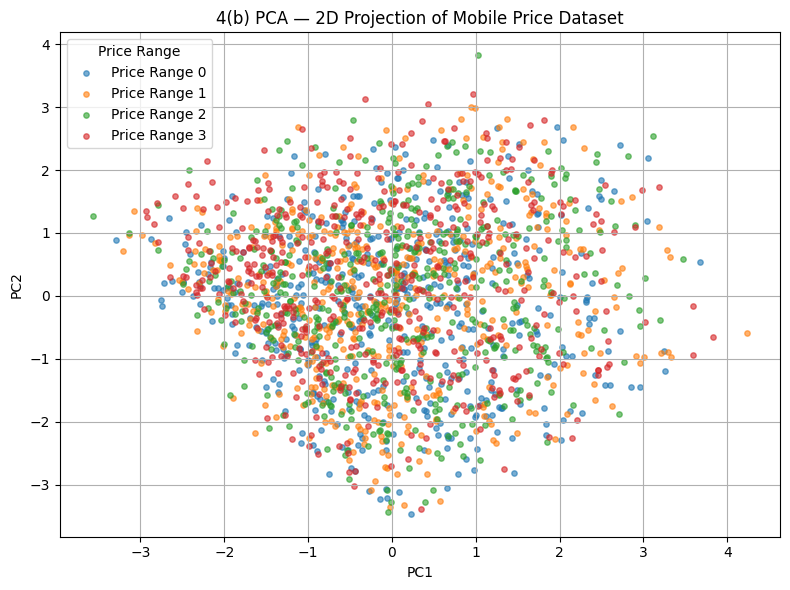


4(c) Adjusted Rand Score — All Features: 0.0060


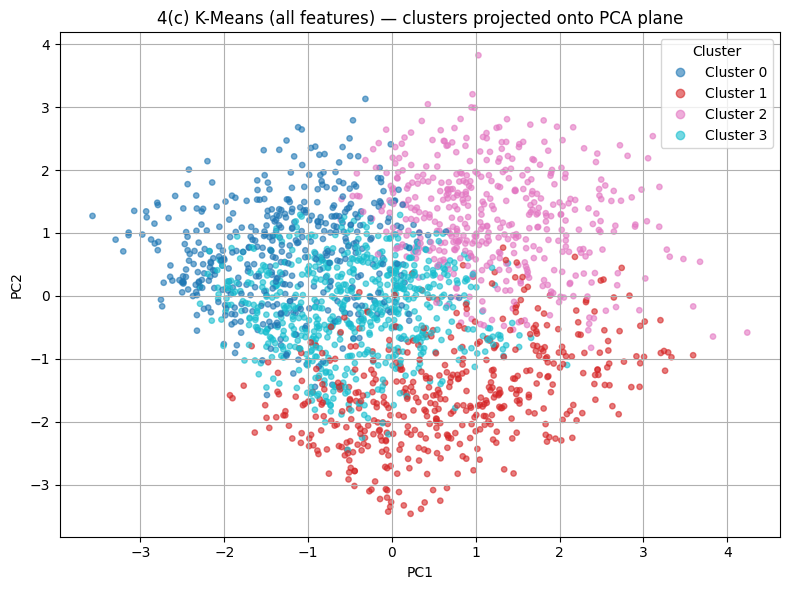

4(d) Adjusted Rand Score — PCA 2D Features: 0.0017


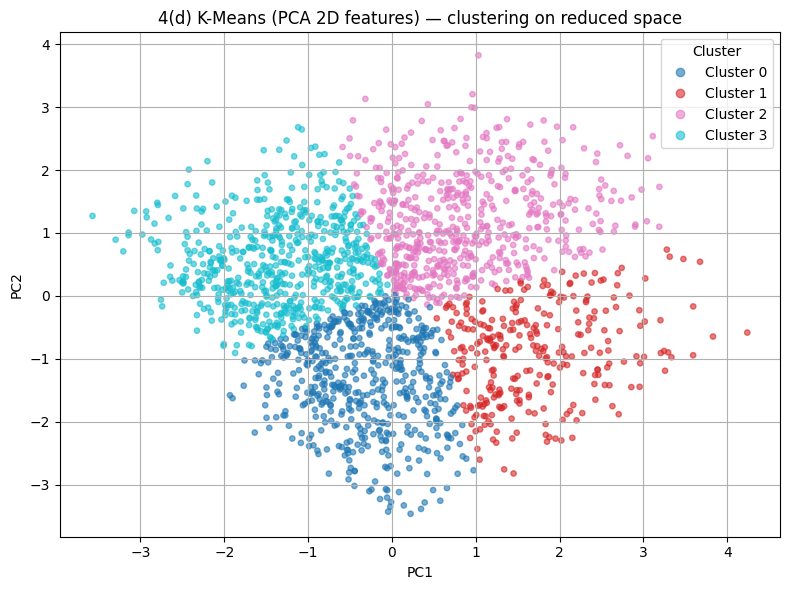

In [ ]:
# ── Q4 Imports ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# ── 4(a): Standardise features with z-score (StandardScaler) ────────────────
scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(df.drop(columns=['price_range']))
y_true   = df['price_range'].values

# ── 4(b): PCA → 2D, scatter plot coloured by ground-truth class label ────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance by PC1 & PC2: "
      f"{pca.explained_variance_ratio_[0]:.3f} + {pca.explained_variance_ratio_[1]:.3f} "
      f"= {sum(pca.explained_variance_ratio_):.3f}")

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
plt.figure(figsize=(8, 6))
for label in np.unique(y_true):                            # ← loop only adds scatter points
    mask = y_true == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Price Range {label}',
                alpha=0.6, s=15, color=colors[label])
# title / labels / legend OUTSIDE the loop ← FIX for the indentation bug
plt.title("4(b) PCA — 2D Projection of Mobile Price Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Price Range")
plt.grid(True)
plt.tight_layout()
plt.show()

# ── 4(c): K-Means on ALL (standardised) features ─────────────────────────────
kmeans_all  = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_all = kmeans_all.fit_predict(X_scaled)
ars_all      = adjusted_rand_score(y_true, clusters_all)
print(f"\n4(c) Adjusted Rand Score — All Features: {ars_all:.4f}")

# Visualise 4(c): project cluster labels onto the PCA plane for 2D display
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=clusters_all, cmap='tab10', alpha=0.6, s=15)
plt.title("4(c) K-Means (all features) — clusters projected onto PCA plane")
plt.xlabel("PC1")
plt.ylabel("PC2")
handles, _ = scatter.legend_elements()
plt.legend(handles, [f'Cluster {i}' for i in range(4)], title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# ── 4(d): K-Means on 2D PCA features ────────────────────────────────────────
kmeans_pca  = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)
ars_pca      = adjusted_rand_score(y_true, clusters_pca)
print(f"4(d) Adjusted Rand Score — PCA 2D Features: {ars_pca:.4f}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=clusters_pca, cmap='tab10', alpha=0.6, s=15)
plt.title("4(d) K-Means (PCA 2D features) — clustering on reduced space")
plt.xlabel("PC1")
plt.ylabel("PC2")
handles, _ = scatter.legend_elements()
plt.legend(handles, [f'Cluster {i}' for i in range(4)], title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# ── Q5: Enhanced K-Means with ARM Feature Enrichment ──────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score
from scipy.optimize import linear_sum_assignment

# ── Hungarian-algorithm label mapper ────────────────────────────────────────
# K-Means cluster IDs are arbitrary; this function finds the optimal
# permutation that maximises overlap with ground-truth labels.
def map_clusters(y_true, y_pred):
    classes = np.unique(y_true)
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for i, true_cls in enumerate(classes):
        for j, pred_cls in enumerate(np.unique(y_pred)):
            cm[i, j] = np.sum((y_true == true_cls) & (y_pred == pred_cls))
    row_ind, col_ind = linear_sum_assignment(-cm)
    pred_classes = np.unique(y_pred)
    mapping = {pred_classes[c]: classes[r] for r, c in zip(row_ind, col_ind)}
    return np.array([mapping[l] for l in y_pred])

def compute_metrics(y_true, y_pred_mapped):
    return {
        'acc':  accuracy_score(y_true, y_pred_mapped),
        'prec': precision_score(y_true, y_pred_mapped, average='macro', zero_division=0),
        'rec':  recall_score(y_true, y_pred_mapped, average='macro', zero_division=0),
        'f1':   f1_score(y_true, y_pred_mapped, average='macro', zero_division=0),
    }

X_features = df.drop(columns=['price_range']).values
y_labels   = df['price_range'].values
seeds      = [0, 10, 42, 100, 999]

# ── MinMax scale (keeps inter-feature distances meaningful) ──────────────────
scaler_mm = MinMaxScaler()
X_scaled_mm = scaler_mm.fit_transform(X_features)

# ════════════════════════════════════════
# Baseline: standard K-Means
# ════════════════════════════════════════
print("Running baseline K-Means …")
std_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
for s in seeds:
    raw_preds  = KMeans(n_clusters=4, random_state=s, n_init=10).fit_predict(X_scaled_mm)
    mapped     = map_clusters(y_labels, raw_preds)
    m          = compute_metrics(y_labels, mapped)
    for k in std_metrics: std_metrics[k].append(m[k])

# ════════════════════════════════════════
# ARM Feature Enrichment
# ════════════════════════════════════════

# Step A — discretise ALL features into low / med / high using tertile cuts
df_features = df.drop(columns=['price_range'])
trans_q5 = []
q33 = df_features.quantile(0.33)
q66 = df_features.quantile(0.66)

for _, row in df_features.iterrows():
    t = []
    for col in df_features.columns:
        v = row[col]
        if   v <= q33[col]: t.append(f"{col}_low")
        elif v >= q66[col]: t.append(f"{col}_high")
        else:               t.append(f"{col}_med")
    trans_q5.append(t)

# Step B — mine frequent patterns
te_q5 = TransactionEncoder()
df_trans_q5 = pd.DataFrame(
    te_q5.fit(trans_q5).transform(trans_q5),
    columns=te_q5.columns_
)
fp_q5 = fpgrowth(df_trans_q5, min_support=0.2, use_colnames=True)

# Keep only multi-item patterns (length >= 2) — single items add no new info
top_patterns = (
    fp_q5[fp_q5['itemsets'].apply(len) >= 2]
    .nlargest(20, 'support')
    .reset_index(drop=True)
)
print(f"\nTop ARM patterns used as new features ({len(top_patterns)}):")
print(top_patterns.to_string(index=False))

# Step C — create binary indicator columns for each pattern
X_enriched = pd.DataFrame(X_scaled_mm.copy(), columns=df_features.columns)
for i, row in top_patterns.iterrows():
    items = list(row['itemsets'])
    X_enriched[f"ARM_Pat_{i}"] = df_trans_q5[items].all(axis=1).astype(float)

# Re-scale so new binary columns are on the same [0,1] scale
scaler_mm2  = MinMaxScaler()
X_enr_scaled = scaler_mm2.fit_transform(X_enriched)
print(f"\nEnriched feature matrix shape: {X_enr_scaled.shape}")

# Step D — improved K-Means on enriched features
print("\nRunning improved K-Means …")
imp_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
for s in seeds:
    raw_preds  = KMeans(n_clusters=4, random_state=s, n_init=10).fit_predict(X_enr_scaled)
    mapped     = map_clusters(y_labels, raw_preds)
    m          = compute_metrics(y_labels, mapped)
    for k in imp_metrics: imp_metrics[k].append(m[k])

# ════════════════════════════════════════
# Per-seed breakdown
# ════════════════════════════════════════
print("\n=== Per-Seed Results ===")
print(f"{'Seed':<6} | {'Orig Acc':>8} | {'Imp Acc':>7} | {'Orig F1':>7} | {'Imp F1':>6}")
print("-" * 48)
for i, s in enumerate(seeds):
    print(f"{s:<6} | {std_metrics['acc'][i]:>8.4f} | {imp_metrics['acc'][i]:>7.4f} |"
          f" {std_metrics['f1'][i]:>7.4f} | {imp_metrics['f1'][i]:>6.4f}")

# ════════════════════════════════════════
# Average comparison table
# ════════════════════════════════════════
print("\n=== Average Performance over Seeds [0, 10, 42, 100, 999] ===")
header = f"{'Metric':<12} | {'Original K-Means':>17} | {'ARM-Enriched K-Means':>20} | {'Delta':>6}"
print(header)
print("-" * len(header))
for metric, label in [('acc','Accuracy'), ('prec','Precision'),
                       ('rec','Recall'),   ('f1','F1-Score')]:
    orig = np.mean(std_metrics[metric])
    imp  = np.mean(imp_metrics[metric])
    print(f"{label:<12} | {orig:>17.4f} | {imp:>20.4f} | {imp-orig:>+6.4f}")


Running baseline K-Means …

Top ARM patterns used as new features (20):
 support                         itemsets
  0.5215       (four_g_high, three_g_low)
  0.5095     (three_g_low, dual_sim_high)
  0.5070         (wifi_high, three_g_low)
  0.5050          (blue_low, three_g_low)
  0.5030 (touch_screen_high, three_g_low)
  0.4970  (touch_screen_low, three_g_low)
  0.4950         (blue_high, three_g_low)
  0.4930          (wifi_low, three_g_low)
  0.4905      (dual_sim_low, three_g_low)
  0.4785        (four_g_low, three_g_low)
  0.3945           (fc_high, three_g_low)
  0.3910         (sc_w_high, three_g_low)
  0.3825            (pc_low, three_g_low)
  0.3740     (talk_time_low, three_g_low)
  0.3725    (three_g_low, talk_time_high)
  0.3725          (sc_w_low, three_g_low)
  0.3725      (n_cores_high, three_g_low)
  0.3715           (pc_high, three_g_low)
  0.3675       (n_cores_low, three_g_low)
  0.3660         (m_dep_low, three_g_low)

Enriched feature matrix shape: (2000, 40)

Ru

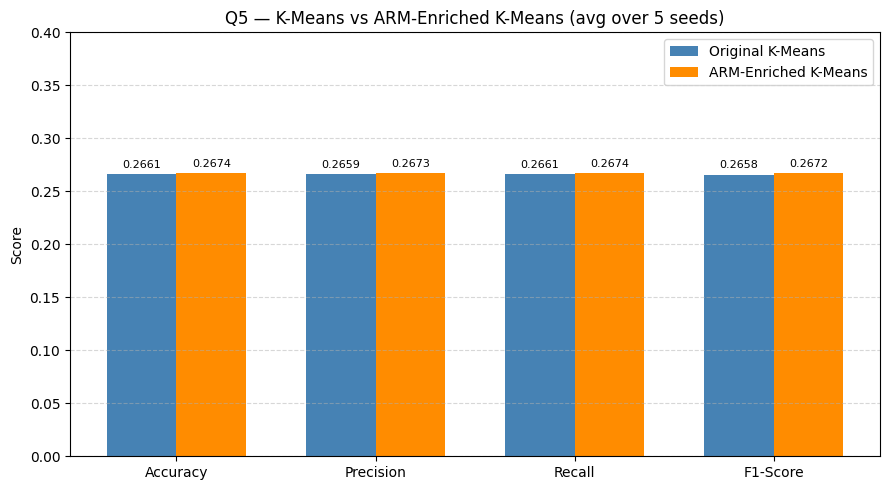

In [ ]:
# ── Q5 Visualisation — bar chart comparison ─────────────────────────────────
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
keys           = ['acc', 'prec', 'rec', 'f1']

orig_means = [np.mean(std_metrics[k]) for k in keys]
imp_means  = [np.mean(imp_metrics[k]) for k in keys]

x   = np.arange(len(metrics_labels))
w   = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, orig_means, w, label='Original K-Means',      color='steelblue')
bars2 = ax.bar(x + w/2, imp_means,  w, label='ARM-Enriched K-Means',   color='darkorange')

ax.set_title('Q5 — K-Means vs ARM-Enriched K-Means (avg over 5 seeds)')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 0.4)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


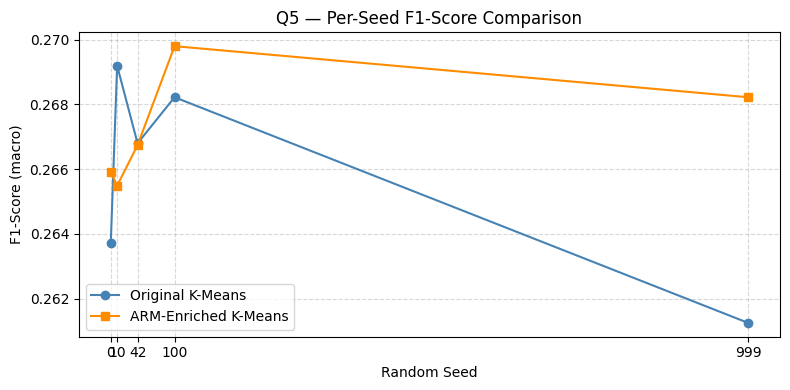

In [ ]:
# ── Q5 Per-seed F1 comparison line plot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(seeds, std_metrics['f1'], marker='o', label='Original K-Means',    color='steelblue')
ax.plot(seeds, imp_metrics['f1'], marker='s', label='ARM-Enriched K-Means', color='darkorange')
ax.set_title('Q5 — Per-Seed F1-Score Comparison')
ax.set_xlabel('Random Seed')
ax.set_ylabel('F1-Score (macro)')
ax.set_xticks(seeds)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
